In [1]:
import requests
import pandas as pd
import folium
import plotly
import re
import matplotlib.pyplot as plt


In [2]:
year = 2022

# Svalbard EPSG:4326
polygon_Holtedahlfonna_init= [
    [79.004328, 13.456459],
    [79.071166, 15.104427],
    [78.854586, 15.31317],
    [78.801382, 13.819012],
    [79.004328, 13.456459]
    ]

polygon_Kongsevegen_init = [
  [78.738532, 12.358704 ],   
  [78.886054, 12.358704],   
  [78.886054, 13.201904],
  [78.738532, 13.201904],   
  [78.738532, 12.358704 ]    
]


## Map Locations

In [3]:
#Make a function to map one location using folium
def map_location(polygon, zoom_start=8):
    m = folium.Map(location=[polygon[0][0], polygon[0][1]], zoom_start=zoom_start)
    folium.Polygon(polygon, color='blue', fill=True, fill_color='cyan').add_to(m)
    return m

In [4]:
map_location(polygon_Kongsevegen_init)

In [5]:
#Swap lat and long
polygon_Holtedahlfonna = [[x[1], x[0]] for x in polygon_Holtedahlfonna_init]
polygon_Kongsevegen = [[x[1], x[0]] for x in polygon_Kongsevegen_init]


## Getting data w request

In [6]:
import pandas as pd
import requests

def get_data(polygon: list, year_beginning: int,year_end: int, mode: str, level: str, satellite: str, collection: str = 'SENTINEL-1',
             orderby: str = "ContentDate/Start", top: int = 1000) -> pd.DataFrame:
    """
    Retrieves historical data for a given polygon and year from the Copernicus Data Space Catalogue.

    Args:
    polygon (list[list]): A list of [latitude, longitude] pairs defining the polygon area of interest.
    year (int): The year for which data is to be retrieved.
    mode (str): The acquisition mode, 'IW' for Interferometric Wide swath or 'EW' for Extra Wide swath.
    level (str): The data level, 'RAW' for raw data or 'SLC' for Single Look Complex.
    satellite (str): The satellite, 'S1A' for Sentinel-1A, 'S1B' for Sentinel-1B, or 'BOTH' for both.
    collection (str, optional): The name of the collection to query. Default is 'SENTINEL-1'.
    orderby (str, optional): The order by which to sort the results. Default is "ContentDate/Start".
    top (int, optional): The maximum number of results to return. Default is 1000.

    Returns:
    pd.DataFrame: A DataFrame containing the retrieved data.

    Raises:
    HTTPError: If the request to the Copernicus Data Space Catalogue fails.
    """
    base_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
    polygon_str = ",".join([f"{x[0]} {x[1]}" for x in polygon])

    if satellite == 'BOTH':
        contains = f"(contains(Name, 'S1A_{mode}_{level}') or contains(Name, 'S1B_{mode}_{level}'))"
    else:
        contains = f"contains(Name, '{satellite}_{mode}_{level}')"

    print(contains)

    filter_params = [
        f"Collection/Name eq '{collection}'",
        contains,
        f"OData.CSC.Intersects(area=geography'SRID=4326;POLYGON(({polygon_str}))')",
        f"ContentDate/Start gt {year_beginning}-01-01T00:00:00.000Z",
        f"ContentDate/Start lt {year_end}-01-01T00:00:00.000Z",
    ]
    
    params = {
        "$filter": " and ".join(filter_params),
        "$orderby": orderby,
        "$top": str(top),
    }

    response = requests.get(url=base_url, params=params)
    response.raise_for_status()
    
    df = pd.DataFrame.from_dict(response.json()['value'])
   

    # Extract 'Start' date from 'ContentDate' and add it as a new column
    if 'ContentDate' in df.columns:
        df['timestamp'] = pd.to_datetime(df['ContentDate'].apply(lambda x: x['Start']))
        print("ContentDate found")
    else:
        df['timestamp'] = pd.NaT  # Set as Not-a-Time (NaT) if 'ContentDate' is not present
        print("ContentDate not found")


    #df['polarisation'] = df['Name'].str.extract(r'(1SSV|1SSH|1SDH|1SDV)')
    #df['satellite'] = df['Name'].str.extract(r'(S1A|S1B)')
    data = df['Name'].astype(str)
    split_data = data.str.split('_', expand=True)
    naming_columns = ['satellite', 'mode', 'TTTR', 'polarisation', 'Start DateTime', 'Stop DateTime', 'Absolute_Orbit', 'Mission ID', 'Product ID', 'extra']
    df[naming_columns] = split_data

    #If timestamp.hour is 6 or 5, assign orbit = descending else assign orbit = ascending
    df['orbit'] = df['timestamp'].apply(lambda x: 'Descending' if x.hour in [6] else 'Ascending')

    #Assign relative orbit number
    df.loc[df['satellite'] == 'S1A', 'relat_orbit'] = ((df['Absolute_Orbit'].astype(int)-73) % 175)+1
    df.loc[df['satellite'] == 'S1B', 'relat_orbit'] = ((df['Absolute_Orbit'].astype(int)-27) % 175)+1

    return df

# Create timestamp from ContentDate
ts = lambda x: [x['ContentDate'].to_dict()[i]['Start'] for i in range(len(x['ContentDate']))]


In [7]:
#Plotting comparison of 2 locations
def plot_comparison(Name1, polygon1, Name2, polygon2,year_beginning, year_end, mode, level, satellite ):
    df1 = get_data(polygon1, year_beginning, year_end, mode, level, satellite)
    df1['timestamp'] = pd.to_datetime(ts(df1))
    #Print info 
    print(f"Total number of products for {Name1} = {len(df1)}")
    print("first name of product: ", df1['Name'][0])
    df2 = get_data(polygon2, year_beginning, year_end, mode, level, satellite)
    df2['timestamp'] = pd.to_datetime(ts(df2))
    monthly_counts1 = df1['timestamp'].dt.to_period('Y').value_counts().sort_index()
    monthly_counts2 = df2['timestamp'].dt.to_period('Y').value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(12, 6))
    if len(df1) > len(df2):
        ax.bar(monthly_counts1.index.astype(str), monthly_counts1.values, label=Name1)
        ax.bar(monthly_counts2.index.astype(str), monthly_counts2.values, label=Name2)
    else:
        ax.bar(monthly_counts2.index.astype(str), monthly_counts2.values, label=Name2)
        ax.bar(monthly_counts1.index.astype(str), monthly_counts1.values, label=Name1)

    ax.set_xlabel('Year')
    ax.set_ylabel('Number of products')
    ax.set_title(" From " + str(year_beginning) + " to " + str(year_end) +"," + f"Total number of {mode} {level} products for {Name1} = {len(df1) } & {Name2} = {len(df2)}" )
    ax.legend()
    plt.show()


(contains(Name, 'S1A_IW_GRD') or contains(Name, 'S1B_IW_GRD'))
ContentDate found
Total number of products for Holtedahlfonna = 500
first name of product:  S1A_IW_GRDH_1SSH_20150120T061504_20150120T061529_004251_0052CA_4922_COG.SAFE
(contains(Name, 'S1A_IW_GRD') or contains(Name, 'S1B_IW_GRD'))
ContentDate found


/var/folders/g7/2783kfj16zj6nhq_m66yk50m0000gp/T/ipykernel_3467/1186196704.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_counts1 = df1['timestamp'].dt.to_period('Y').value_counts().sort_index()
/var/folders/g7/2783kfj16zj6nhq_m66yk50m0000gp/T/ipykernel_3467/1186196704.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_counts2 = df2['timestamp'].dt.to_period('Y').value_counts().sort_index()


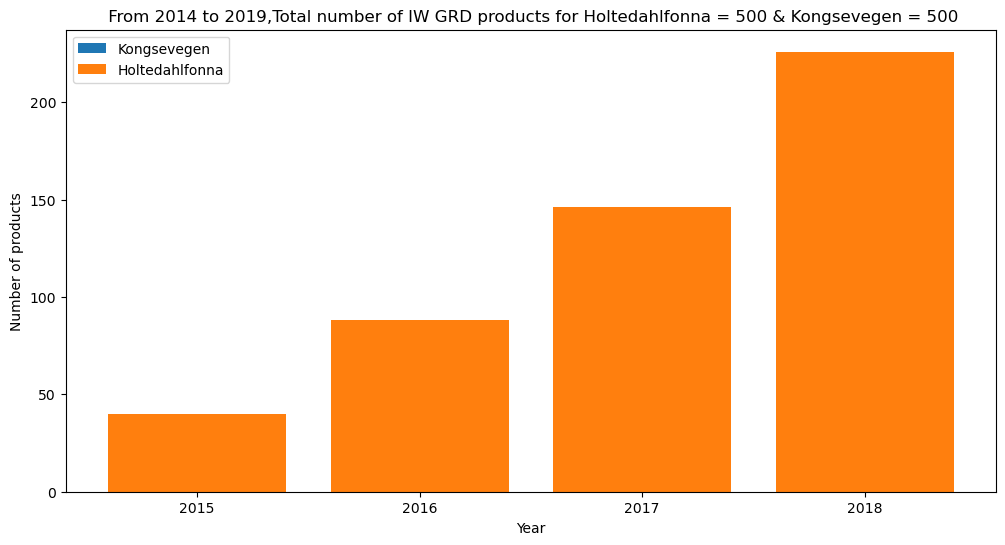

In [8]:
#plot Svalabard vs alpes
mode_land = 'IW'
level_land = 'RAW'
plot_comparison('Holtedahlfonna', polygon_Holtedahlfonna, 'Kongsevegen',polygon_Kongsevegen, year_beginning=2014, year_end=2019, mode=mode_land, level='GRD', satellite='BOTH')

(contains(Name, 'S1A_IW_GRD') or contains(Name, 'S1B_IW_GRD'))
ContentDate found
Total number of products for Holtedahlfonna = 545
first name of product:  S1B_IW_GRDH_1SDH_20200102T154457_20200102T154522_019640_0251E4_2855.SAFE
(contains(Name, 'S1A_IW_GRD') or contains(Name, 'S1B_IW_GRD'))
ContentDate found


/var/folders/g7/2783kfj16zj6nhq_m66yk50m0000gp/T/ipykernel_3467/1186196704.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_counts1 = df1['timestamp'].dt.to_period('Y').value_counts().sort_index()
/var/folders/g7/2783kfj16zj6nhq_m66yk50m0000gp/T/ipykernel_3467/1186196704.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_counts2 = df2['timestamp'].dt.to_period('Y').value_counts().sort_index()


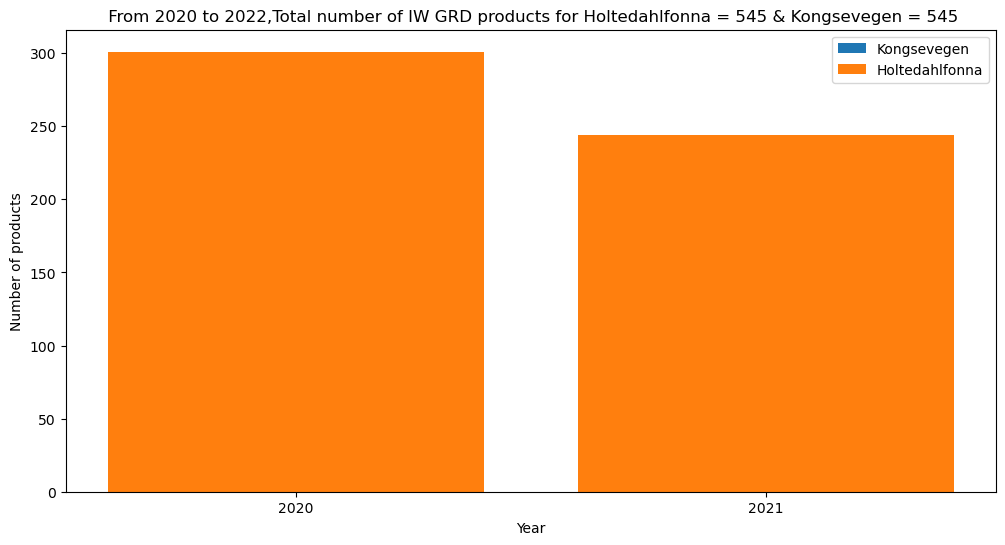

In [9]:
#plot Svalabard vs alpes
mode_land = 'IW'
level_land = 'RAW'
plot_comparison('Holtedahlfonna', polygon_Holtedahlfonna, 'Kongsevegen',polygon_Kongsevegen, year_beginning=2020, year_end=2022, mode=mode_land, level='GRD', satellite='BOTH')

In [10]:
#plot Svalabard vs alpes
mode_land = 'IW'
level_land = 'RAW'
plot_comparison('Holtedahlfonna', polygon_Holtedahlfonna, 'Kongsevegen',polygon_Kongsevegen, year_beginning=2023, year_end=2024, mode=mode_land, level='GRD', satellite='BOTH')

(contains(Name, 'S1A_IW_GRD') or contains(Name, 'S1B_IW_GRD'))
ContentDate found
Total number of products for Holtedahlfonna = 116
first name of product:  S1A_IW_GRDH_1SDV_20230102T061547_20230102T061612_046601_0595B9_8E5C.SAFE
(contains(Name, 'S1A_IW_GRD') or contains(Name, 'S1B_IW_GRD'))


In [11]:
#Getting all the data across the years in one dataframe
mode_land = 'EW'
level_land = 'GRD'
satellite = 'BOTH'
year_beginning = 2014
year_end = 2024

In [12]:


#For Holtedahlfonna
df_Holtedahlfonna_2014_2019 = get_data(polygon_Holtedahlfonna, 2014, 2019, mode_land, level_land, satellite)
df_Holtedahlfonna_2020_2022 = get_data(polygon_Holtedahlfonna, 2020, 2022, mode_land, level_land, satellite)
df_Holtedahlfonna_2013_2015 = get_data(polygon_Holtedahlfonna, 2023, 2025, mode_land, level_land, satellite)

(contains(Name, 'S1A_EW_GRD') or contains(Name, 'S1B_EW_GRD'))
ContentDate found
(contains(Name, 'S1A_EW_GRD') or contains(Name, 'S1B_EW_GRD'))
ContentDate found
(contains(Name, 'S1A_EW_GRD') or contains(Name, 'S1B_EW_GRD'))
ContentDate found


In [13]:
#concatenate the dataframes & remove empty rows
df_Holtedahlfonna = pd.concat([df_Holtedahlfonna_2014_2019, df_Holtedahlfonna_2020_2022, df_Holtedahlfonna_2013_2015])
df_Holtedahlfonna_filtered = df_Holtedahlfonna[df_Holtedahlfonna['ContentLength'] != 0]

In [14]:
#info
#Count number of scenes per polarisation   
print(df_Holtedahlfonna_filtered['polarisation'].value_counts())

#Count number of scenes per satellite
print(df_Holtedahlfonna_filtered['satellite'].value_counts())

#Count number of scenes per orbit
print(df_Holtedahlfonna_filtered['orbit'].value_counts())


polarisation
1SDH    2398
1SSH      20
Name: count, dtype: int64
satellite
S1A    1824
S1B     594
Name: count, dtype: int64
orbit
Descending    1253
Ascending     1165
Name: count, dtype: int64


In [15]:
#for given path, calculate number of scenes per polarisation
counts_pol_ascending = df_Holtedahlfonna_filtered[df_Holtedahlfonna_filtered['orbit'] == 'ASCENDING']['polarisation'].value_counts()
print("Amount of each polarisations for the ascending path is the following:", counts_pol_ascending)

counts_pol_descending = df_Holtedahlfonna_filtered[df_Holtedahlfonna_filtered['orbit'] == 'DESCENDING']['polarisation'].value_counts()
print("Amount of each polarisations for the descending path is the following:", counts_pol_descending)

Amount of each polarisations for the ascending path is the following: Series([], Name: count, dtype: int64)
Amount of each polarisations for the descending path is the following: Series([], Name: count, dtype: int64)


C:\Users\MarionD\AppData\Local\Temp\ipykernel_40028\3405110522.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Holtedahlfonna_filtered['year'] = df_Holtedahlfonna_filtered['timestamp'].dt.year


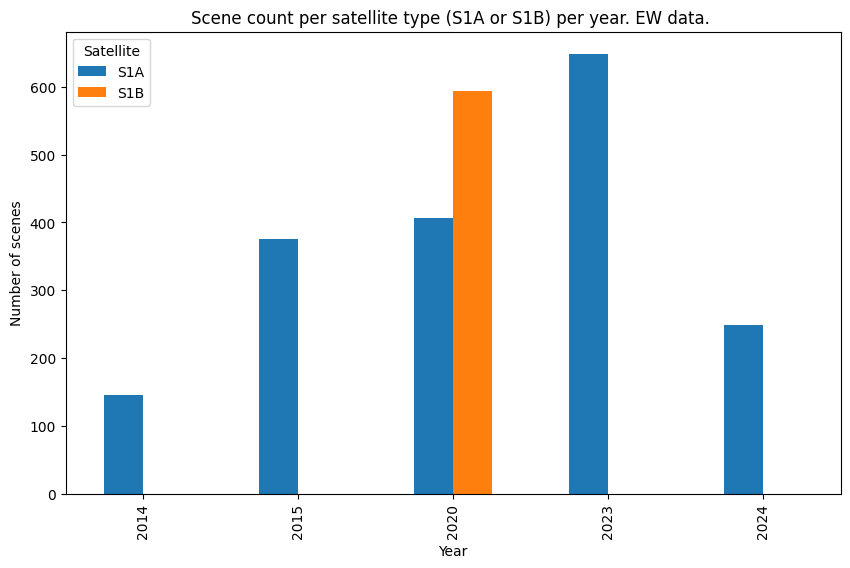

In [16]:
# Scene count per satellite type
df_Holtedahlfonna['year'] = df_Holtedahlfonna['timestamp'].dt.year
df_Holtedahlfonna_filtered['year'] = df_Holtedahlfonna_filtered['timestamp'].dt.year
grouped_data = df_Holtedahlfonna_filtered.groupby(['year', 'satellite']).size().unstack()

# Plotting
grouped_data.plot(kind='bar', stacked=False, figsize=(10, 6))

# Adding title and labels
plt.title('Scene count per satellite type (S1A or S1B) per year. EW data. ')
plt.ylabel('Number of scenes')
plt.xlabel('Year')

# Adjusting legend
plt.legend(title='Satellite', loc='upper left')

plt.show()


C:\Users\MarionD\AppData\Local\Temp\ipykernel_40028\2004002504.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Holtedahlfonna_filtered['polarisation'] = df_Holtedahlfonna_filtered['polarisation'].replace({'1SDV': 'VV+VH', '1SDH': 'HH+HV', '1SSV': 'VV', '1SSH': 'HH'})


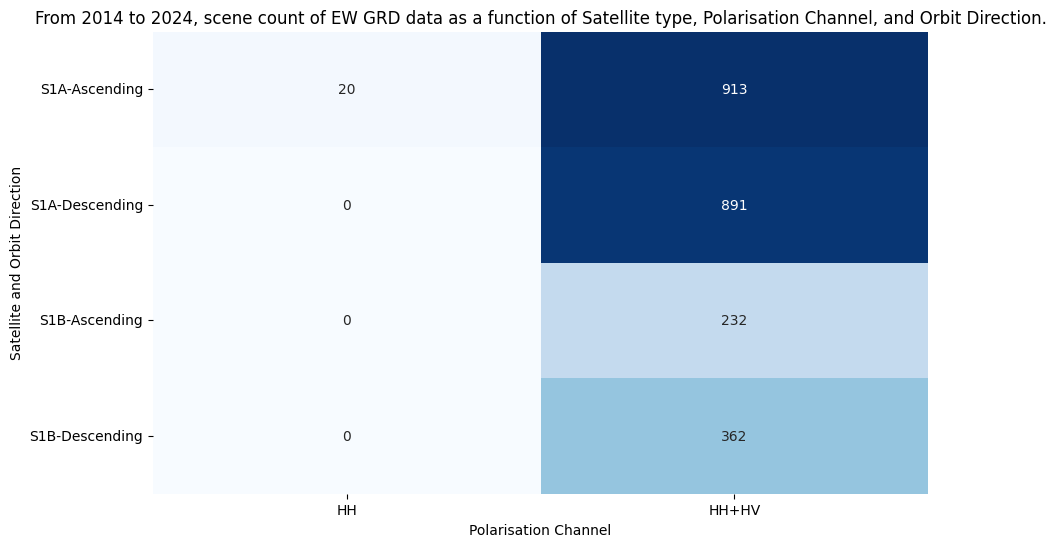

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#remane the polarisation channels as HH+HV, VV+VH, HH
df_Holtedahlfonna_filtered['polarisation'] = df_Holtedahlfonna_filtered['polarisation'].replace({'1SDV': 'VV+VH', '1SDH': 'HH+HV', '1SSV': 'VV', '1SSH': 'HH'})

# Create a pivot table
pivot_table = df_Holtedahlfonna_filtered.groupby(['satellite', 'orbit', 'polarisation']).size().unstack(fill_value=0)

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.title('From ' + str(year_beginning) + " to " + str(year_end) + ',' +  ' scene count of EW GRD data as a function of Satellite type, Polarisation Channel, and Orbit Direction.')
plt.xlabel('Polarisation Channel')
plt.ylabel('Satellite and Orbit Direction')
plt.yticks(rotation=0)

plt.show()




In [18]:
df_Holtedahlfonna_filtered.head()

,@odata.mediaContentType,Id,Name,ContentType,ContentLength,OriginDate,PublicationDate,ModificationDate,Online,EvictionDate,...,polarisation,Start DateTime,Stop DateTime,Absolute_Orbit,Mission ID,Product ID,extra,orbit,relat_orbit,year
0,application/octet-stream,8faf4a10-1150-4384-8b9e-98f211f69a12,S1A_EW_GRDM_1SDH_20141004T061501_20141004T0616...,application/octet-stream,295647120,2023-04-24T08:09:17.084Z,2023-04-24T10:32:59.632Z,2023-04-24T10:32:59.632Z,True,,...,HH+HV,20141004T061501,20141004T061601,002676,002FBD,4A54,COG.SAFE,Descending,154.0,2014
1,application/octet-stream,c3424caf-0248-4f00-98fb-fef38d5d2d22,S1A_EW_GRDH_1SDH_20141004T061501_20141004T0616...,application/octet-stream,819549542,2023-04-24T08:09:13.184Z,2023-04-24T10:58:13.447Z,2023-04-24T10:58:13.447Z,True,,...,HH+HV,20141004T061501,20141004T061601,002676,002FBD,3DBC,COG.SAFE,Descending,154.0,2014
4,application/octet-stream,c59713ec-a955-402a-828a-1ddbca97347b,S1A_EW_GRDH_1SDH_20141005T065556_20141005T0656...,application/octet-stream,771369754,2023-04-24T14:34:33.520Z,2023-04-24T16:39:44.818Z,2023-04-24T16:39:44.818Z,True,,...,HH+HV,20141005T065556,20141005T065656,002691,003016,45F1,COG.SAFE,Descending,169.0,2014
6,application/octet-stream,e7316d92-d2a5-460a-b463-e43609b61344,S1A_EW_GRDM_1SDH_20141005T065556_20141005T0656...,application/octet-stream,274714445,2023-04-24T14:34:39.145Z,2023-04-24T16:36:52.710Z,2023-04-24T16:36:52.710Z,True,,...,HH+HV,20141005T065556,20141005T065656,002691,003016,C726,COG.SAFE,Descending,169.0,2014
8,application/octet-stream,ce4db8c5-d3be-4ca4-a70e-4689c5cbf5cf,S1A_EW_GRDH_1SDH_20141005T150347_20141005T1504...,application/octet-stream,828839200,2023-04-24T15:15:05.474Z,2023-04-24T17:19:03.561Z,2023-04-24T17:19:03.561Z,True,,...,HH+HV,20141005T150347,20141005T150447,002696,003030,1404,COG.SAFE,Ascending,174.0,2014


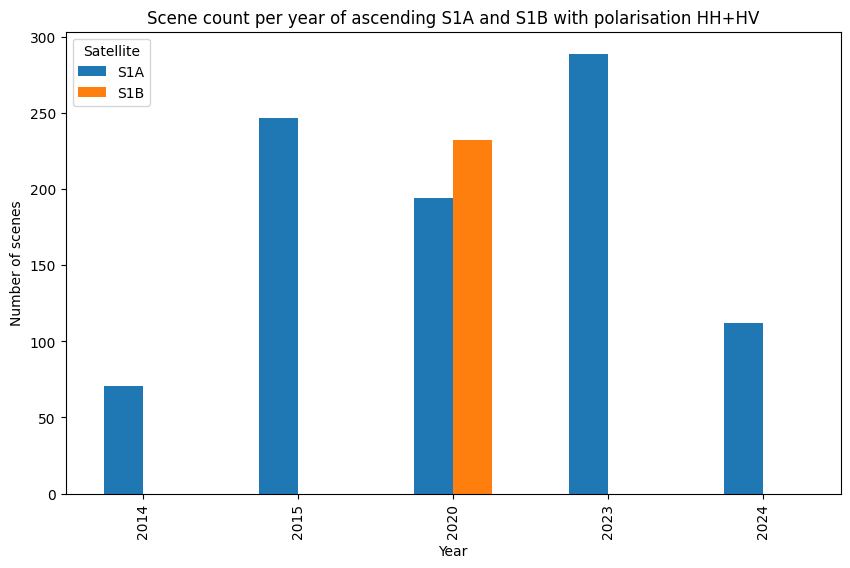

In [19]:
#find scene count per year of ascending S1A and S1B with polarisation 1SDH
count_filter_1 = df_Holtedahlfonna_filtered[(df_Holtedahlfonna_filtered['orbit'] == 'Ascending') & (df_Holtedahlfonna_filtered['polarisation'] == 'HH+HV')].groupby(['year', 'satellite']).size().unstack().plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Scene count per year of ascending S1A and S1B with polarisation HH+HV')
plt.ylabel('Number of scenes')
plt.xlabel('Year')
plt.legend(title='Satellite', loc='upper left')
plt.show()


In [20]:
'''BaseExceptionGroup#find scene count per year of descending S1A and S1B with polarisation 1SDV
count_filter_2 = df_Holtedahlfonna_filtered[(df_Holtedahlfonna_filtered['orbit'] == 'Descending') & (df_Holtedahlfonna_filtered['polarisation'] == 'VV+VH')].groupby(['year', 'satellite']).size().unstack().plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Scene count per year of descending S1A and S1B with polarisation 1SDV')
plt.ylabel('Number of scenes')
plt.xlabel('Year')
plt.legend(title='Satellite', loc='upper left')
plt.show()''' 



"BaseExceptionGroup#find scene count per year of descending S1A and S1B with polarisation 1SDV\ncount_filter_2 = df_Holtedahlfonna_filtered[(df_Holtedahlfonna_filtered['orbit'] == 'Descending') & (df_Holtedahlfonna_filtered['polarisation'] == 'VV+VH')].groupby(['year', 'satellite']).size().unstack().plot(kind='bar', stacked=False, figsize=(10, 6))\nplt.title('Scene count per year of descending S1A and S1B with polarisation 1SDV')\nplt.ylabel('Number of scenes')\nplt.xlabel('Year')\nplt.legend(title='Satellite', loc='upper left')\nplt.show()"

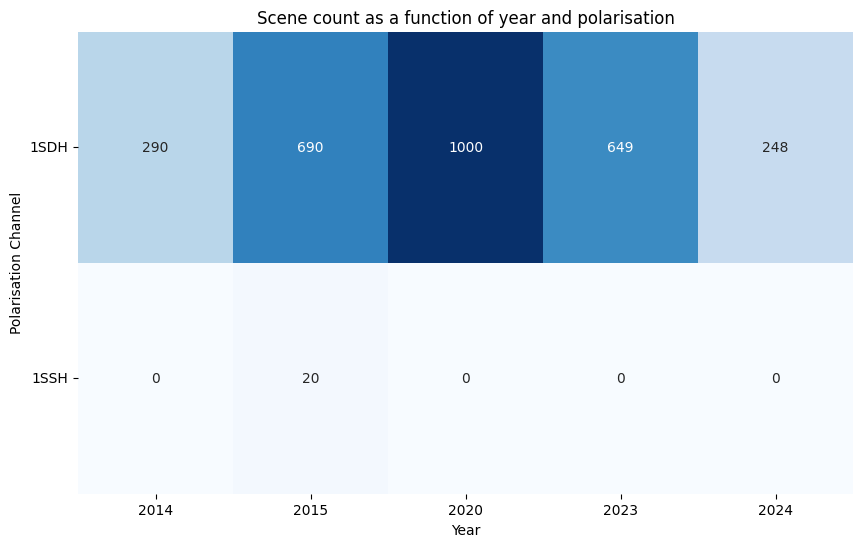

In [21]:
#scene count per year as a function of polarisation
pivot_table = df_Holtedahlfonna.groupby(['polarisation','year']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.title('Scene count as a function of year and polarisation')
plt.xlabel('Year')
plt.ylabel('Polarisation Channel')
plt.yticks(rotation=0)
plt.show()

# Write-up task: data availability

The objective is to understand data availbility to choose the optimal dataset for our training purposes.We are looking at two glaciers in Svalbard: Holtedahlfonna and Kongsevegen. They are located close enough to always be within the same Sentinel-1 scene so the analysis of scene count is equal and relevant for both glaciers. 

### Method:
 We are bounded to look at IW data as we want high resolution land (EW will not offer as precise a resolution though there is a large scene count from there), GRD data as this has already been pre-processed by ESA in-house (the images are already multilooked). Now we still have other filters left: Satellite used (S1A, S1B), polarisation channel (single: HH (SH), VV (SV), dual: VV+VH (DV), HH+HV (DH)) and orbit direction (ascending or descending).

To group the existing scenes, the naming convention of Sentinel-1 products was used for categorising if the scene is from satellite A or B and the specific polarisation channel, as they can easily be extracted from the string in the name. Orbit direction is however only included in the meta-data, but it can be noticed that descending passes for this region only take place at 6am (around 0615) and ascending passes at 3pm (generally 1545). Thus they were labelled according to the timestamp which is also included in the name of the product.
![Alt Text](Sentinel-1-SAR-User-Guide-Naming-Conventions-Figure-1.jpg)

The product information were found and put into a dataframe in subsets to bypass the maximum bound of 1000 products. Then they were all concatneated into one main dataframe. After creating the adequate labels for satellite used, orbit direction, polarisation channel and year they were taken (from the start of the Sentinel-1 in 2014 to now in 2024), the number of scenes was counted and analysed.

### INSIGHTS DATA AVAILABILITY
The pivot plot shows that the largest scene count for both S1A and S1B respectively are for HH+HV ascending passes. Next up being VV+VH in descending passes. The following insights were also observed:
- S1A has more data available than S1B 
- No 1SDH data available for descending pass and inversely no 1SDV data available for ascending passes
- pol H data was taken in the early years of the program but stopped in 2018 onwards. 
- 1SDH spans the øost aøount of years, and the øost amount of scenes per year used.


### Conclusion
- if 1SDH suits glacier classification, then we should use this data from both S1A and S1B ascending passes as it has the most data available.
- we could also use a combinatoin of VV+VH and HH+HV if this is relevant, which would then mean we need to check geocoding is not compormised by having data from ascedning and descending passes. 

### Questions:
- Difference between 1SDV and 1SDH? and do we have a preference for glacier classification (and why)?
- Should I also take a look at EW data? less resolution but more scene counts for this region. 
- Is there a geocoding difference when combining S1A and S1B data? They are of the same orbit direction but being different satellites that might be an issue.
- double check the scene count found for all the years makes sense with copernicus browser